# 02 · Steam and power cycles

Most of the world's electricity comes from steam turbines - in coal, gas, nuclear, biomass, geothermal and
solar-thermal plants alike. The Rankine cycle that runs them is a compact case study in applied
thermodynamics: property tables, energy balances, isentropic processes and the second law all appear in one
calculation. This notebook builds the cycle up from its simplest form and asks what limits its efficiency.

**What you will learn**
- locate states in the steam tables and on the T-s diagram
- analyse the Rankine cycle and its variants
- explain what limits the efficiency and how reheat and superheat help
- size the streams of a power plant

**Before you start:** notebook 01  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import cycles, steam
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## The steam tables as a function
`engthermo.steam` implements the IAPWS-IF97 industrial formulation - the same equations behind commercial
steam tables and power-plant software. Locate a few states:

In [2]:
for T_C, p_bar in ((150, 1), (150, 10), (350, 30), (700, 250)):
    st = steam.state(T=T_C + 273.15, p=p_bar * 1e5)
    print(f"{T_C:4d} degC, {p_bar:5.0f} bar: {st['phase']:<14} h = {st['h']/1e3:8.1f} kJ/kg  s = {st['s']/1e3:.4f} kJ/(kg K)")
wet = steam.state(p=1e5, x=0.5)
print(f"wet steam, 1 bar, x = 0.5: T = {wet['T'] - 273.15:.1f} degC, h = {wet['h']/1e3:.1f} kJ/kg")

 150 degC,     1 bar: vapour         h =   2776.6 kJ/kg  s = 7.6147 kJ/(kg K)
 150 degC,    10 bar: liquid         h =    632.6 kJ/kg  s = 1.8414 kJ/(kg K)
 350 degC,    30 bar: vapour         h =   3116.1 kJ/kg  s = 6.7449 kJ/(kg K)
 700 degC,   250 bar: vapour         h =   3776.4 kJ/kg  s = 6.6706 kJ/(kg K)
wet steam, 1 bar, x = 0.5: T = 99.6 degC, h = 1546.2 kJ/kg


## The simple ideal Rankine cycle
Pump (1 -> 2), boiler (2 -> 3), turbine (3 -> 4), condenser (4 -> 1). A classic textbook case: boiler at 3 MPa,
turbine inlet 350 degC, condenser at 75 kPa (Cengel & Boles, Example 10-1):

In [3]:
rk = cycles.rankine(p_boiler=3e6, p_condenser=75e3, T_inlet=350 + 273.15)
for k, st in rk["states"].items():
    print(f"state {k}: T = {st['T'] - 273.15:6.1f} degC, p = {st['p']/1e5:6.2f} bar, h = {st['h']/1e3:7.1f} kJ/kg, s = {st['s']/1e3:.4f}"
          + (f", x = {st['x']:.3f}" if "x" in st and st["x"] < 1 else ""))
print(f"turbine work {rk['w_turbine']/1e3:.1f}, pump work {rk['w_pump']/1e3:.2f}, heat in {rk['q_in']/1e3:.1f} kJ/kg")
print(f"thermal efficiency {rk['efficiency']:.1%}   (Carnot between the extreme temperatures: "
      f"{cycles.carnot_efficiency(623.15, rk['states']['1']['T']):.1%})")

state 1: T =   91.8 degC, p =   0.75 bar, h =   384.4 kJ/kg, s = 1.2130, x = 0.000
state 2: T =   91.9 degC, p =  30.00 bar, h =   387.4 kJ/kg, s = 1.2130
state 3: T =  350.0 degC, p =  30.00 bar, h =  3116.1 kJ/kg, s = 6.7449
state 4: T =   91.8 degC, p =   0.75 bar, h =  2403.0 kJ/kg, s = 6.7449, x = 0.886
turbine work 713.0, pump work 3.03, heat in 2728.7 kJ/kg
thermal efficiency 26.0%   (Carnot between the extreme temperatures: 41.4%)


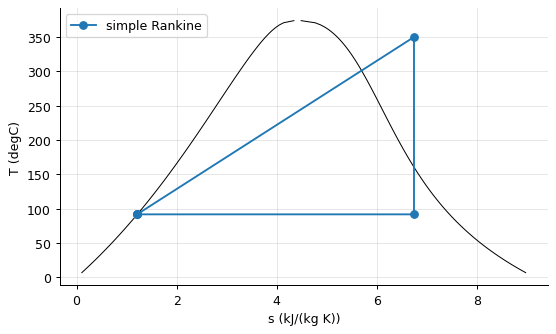

In [4]:
def plot_cycle(rk, label):
    keys = list(rk["states"])
    s = [rk["states"][k]["s"] / 1e3 for k in keys] + [rk["states"][keys[0]]["s"] / 1e3]
    T = [rk["states"][k]["T"] - 273.15 for k in keys] + [rk["states"][keys[0]]["T"] - 273.15]
    plt.plot(s, T, "o-", label=label)
Ts = np.linspace(280, 647, 120)
sats = [steam.saturated(T=T) for T in Ts]
plt.plot([x["liquid"]["s"] / 1e3 for x in sats], Ts - 273.15, "k", lw=0.8); plt.plot([x["vapour"]["s"] / 1e3 for x in sats], Ts - 273.15, "k", lw=0.8)
plot_cycle(rk, "simple Rankine")
plt.xlabel("s (kJ/(kg K))"); plt.ylabel("T (degC)"); plt.legend(); plt.show()

(The straight lines between states are schematic; the boiler path really follows the 3 MPa isobar.) The
efficiency is far below the Carnot limit because heat is added over a range of temperatures - most of it
during boiling at 234 degC, not at 350 degC.

## What raises the efficiency?

In [5]:
base = dict(p_boiler=3e6, p_condenser=75e3, T_inlet=623.15)
variants = {"base case": base,
            "condenser at 10 kPa": {**base, "p_condenser": 10e3},
            "superheat to 600 degC": {**base, "T_inlet": 873.15},
            "boiler at 15 MPa": {**base, "p_boiler": 15e6},
            "all three": {"p_boiler": 15e6, "p_condenser": 10e3, "T_inlet": 873.15}}
rows = [(name, cycles.rankine(**kw)["efficiency"], cycles.rankine(**kw)["exit_quality"], cycles.rankine(**kw)["w_net"] / 1e3) for name, kw in variants.items()]
print(pd.DataFrame(rows, columns=["variant", "efficiency", "turbine exit quality", "w_net (kJ/kg)"]).round(3).to_string(index=False))

              variant  efficiency  turbine exit quality  w_net (kJ/kg)
            base case       0.260                 0.886        710.000
  condenser at 10 kPa       0.334                 0.813        976.964
superheat to 600 degC       0.303                 1.000        997.230
     boiler at 15 MPa       0.327                 0.678        749.440
            all three       0.430                 0.804       1452.924


Every change that raises the *average* temperature of heat addition or lowers the temperature of heat
rejection helps. But raising the boiler pressure lowers the quality at the turbine exit: liquid droplets
erode turbine blades, and a quality below about 0.88-0.90 is not acceptable. Reheating solves that:

## Reheat

without reheat: efficiency 43.0%, exit quality 0.804
with reheat at 4 MPa to 600 degC: efficiency 45.0%, exit quality 0.896


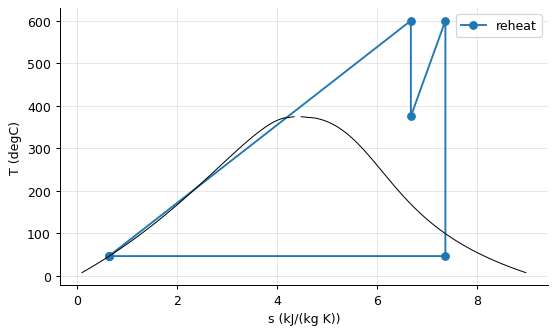

In [6]:
rh = cycles.rankine(p_boiler=15e6, p_condenser=10e3, T_inlet=873.15, reheat=(4e6, 873.15))
no_rh = cycles.rankine(p_boiler=15e6, p_condenser=10e3, T_inlet=873.15)
print(f"without reheat: efficiency {no_rh['efficiency']:.1%}, exit quality {no_rh['exit_quality']:.3f}")
print(f"with reheat at 4 MPa to 600 degC: efficiency {rh['efficiency']:.1%}, exit quality {rh['exit_quality']:.3f}")
plot_cycle(rh, "reheat")
plt.plot([x["liquid"]["s"] / 1e3 for x in sats], Ts - 273.15, "k", lw=0.8); plt.plot([x["vapour"]["s"] / 1e3 for x in sats], Ts - 273.15, "k", lw=0.8)
plt.xlabel("s (kJ/(kg K))"); plt.ylabel("T (degC)"); plt.legend(); plt.show()

Reheat raises the exit quality to a safe value and, because the reheated steam is added at high temperature,
slightly improves the efficiency as well. (Cengel & Boles, Example 10-4: 45.0 % and 89.6 %.)

## Real turbines and pumps

In [7]:
for eta in (1.0, 0.9, 0.8):
    r = cycles.rankine(p_boiler=15e6, p_condenser=10e3, T_inlet=873.15, reheat=(4e6, 873.15), eta_turbine=eta, eta_pump=0.85)
    print(f"turbine isentropic efficiency {eta:.0%}: cycle efficiency {r['efficiency']:.1%}, exit quality {r['exit_quality']:.3f}")

turbine isentropic efficiency 100%: cycle efficiency 45.0%, exit quality 0.896
turbine isentropic efficiency 90%: cycle efficiency 40.9%, exit quality 0.952
turbine isentropic efficiency 80%: cycle efficiency 36.7%, exit quality 1.000


Turbine losses cost efficiency but, as a side effect, raise the exit quality: the lost work reappears as
enthalpy in the exhaust steam.

## Sizing a plant
A 600 MW plant on the reheat cycle with 90 % turbine efficiency:

In [8]:
r = cycles.rankine(p_boiler=15e6, p_condenser=10e3, T_inlet=873.15, reheat=(4e6, 873.15), eta_turbine=0.9, eta_pump=0.85)
P = 600e6
m = P / r["w_net"]
print(f"steam mass flow {m:.0f} kg/s; boiler duty {m * r['q_in']/1e6:.0f} MW; condenser duty {m * r['q_out']/1e6:.0f} MW")
print(f"cooling water (10 K rise, cp 4.18 kJ/(kg K)): {m * r['q_out'] / (4180 * 10):.0f} kg/s")

steam mass flow 381 kg/s; boiler duty 1468 MW; condenser duty 868 MW
cooling water (10 K rise, cp 4.18 kJ/(kg K)): 20772 kg/s


More than half of the fuel's heat leaves through the condenser: cooling towers and the rivers and coasts
that supply cooling water are as much a part of a power station as its boiler.

## Inside the algorithm: the isentropic turbine outlet
At the condenser pressure, the isentropic exit state has the inlet entropy. If that lies between the saturated
liquid and vapour entropies, the state is wet and the quality follows from the lever rule:

In [9]:
inlet = steam.properties(T=623.15, p=3e6)
sat = steam.saturated(p=75e3)
x = (inlet["s"] - sat["liquid"]["s"]) / sat["s_fg"]
h4 = sat["liquid"]["h"] + x * sat["h_fg"]
print(f"by hand: x = {x:.4f}, h4 = {h4/1e3:.1f} kJ/kg;  library: x = {rk['states']['4']['x']:.4f}, h4 = {rk['states']['4']['h']/1e3:.1f} kJ/kg")

by hand: x = 0.8861, h4 = 2403.0 kJ/kg;  library: x = 0.8861, h4 = 2403.0 kJ/kg


## Exercises
1. Plot the thermal efficiency and the exit quality of the simple cycle (3 MPa, 350 degC) against the condenser pressure from 5 to 100 kPa. Why do power plants go to such lengths to keep the condenser cold?
2. For the 15 MPa / 600 degC cycle, vary the reheat pressure from 1 to 8 MPa. Where is the efficiency highest, and what happens to the exit quality?
3. **Implement it yourself:** compute the simple Rankine cycle's efficiency from the four state enthalpies using only `steam.two_phase`, `steam.properties`, `steam.state_ps` and `steam.state_ph`, and compare with `cycles.rankine`.